<a href="https://colab.research.google.com/github/jbarahonab-lang/SYS-2025-2/blob/main/EJERCICIO_25_NOVIEMBRE_CLASE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EJERCICIO 1 CLASE**

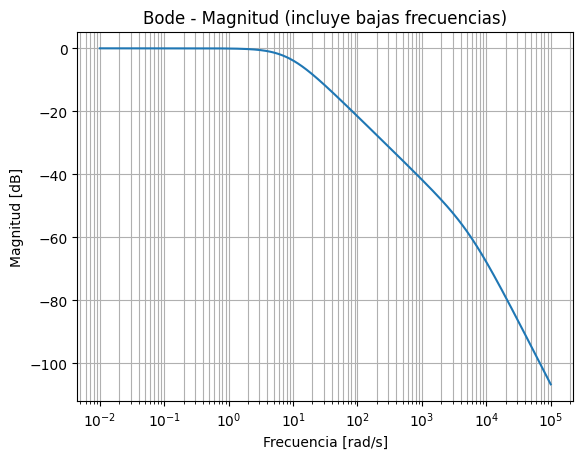

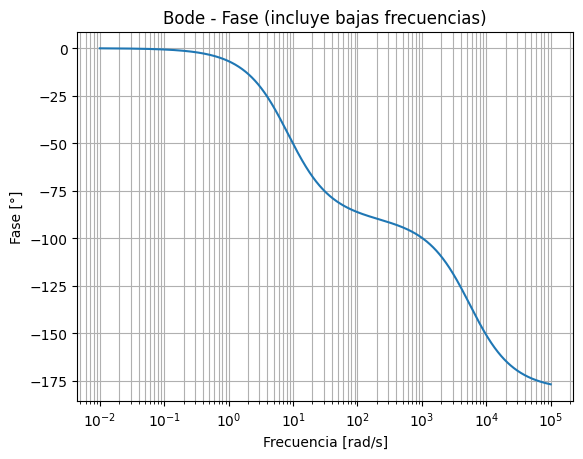

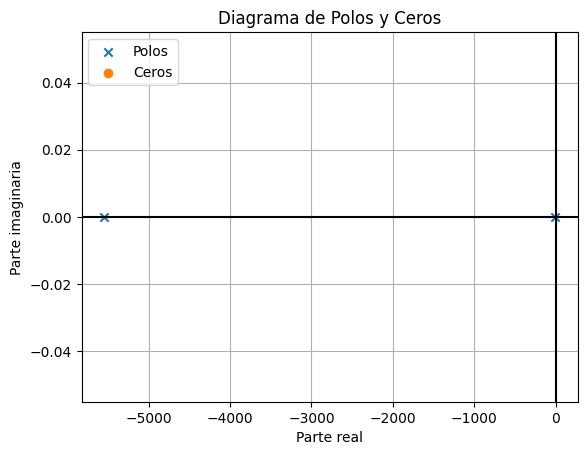

Ceros: []
Polos: [-5547.20968458    -8.34587097]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ============================================
#   PARÁMETROS DEL CIRCUITO
# ============================================
R = 1e3          # 1 kΩ
C = 120e-6       # 120 μF
L = 180e-3       # 180 mH

# ============================================
#   FUNCIÓN DE TRANSFERENCIA H(s)
#   H(s) = 1 / (LC*s^2 + RC*s + 1)
# ============================================
num = [1.0]
den = [L*C, R*C, 1.0]

system = signal.TransferFunction(num, den)

# ============================================
#   FRECUENCIAS DESDE CASI DC (0.01 rad/s)
# ============================================
w = np.logspace(-2, 5, 2000)
w, mag, phase = signal.bode(system, w=w)

# ============================================
#   BODE - MAGNITUD
# ============================================
plt.figure()
plt.semilogx(w, mag)
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Magnitud [dB]")
plt.title("Bode - Magnitud (incluye bajas frecuencias)")
plt.grid(True, which="both")
plt.show()

# ============================================
#   BODE - FASE
# ============================================
plt.figure()
plt.semilogx(w, phase)
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Fase [°]")
plt.title("Bode - Fase (incluye bajas frecuencias)")
plt.grid(True, which="both")
plt.show()

# ============================================
#   DIAGRAMA DE POLOS Y CEROS
# ============================================
zeros, poles, gain = signal.tf2zpk(num, den)

plt.figure()
plt.scatter(np.real(poles), np.imag(poles), marker='x', label="Polos")
plt.scatter(np.real(zeros), np.imag(zeros), marker='o', label="Ceros")
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.xlabel("Parte real")
plt.ylabel("Parte imaginaria")
plt.title("Diagrama de Polos y Ceros")
plt.grid(True)
plt.legend()
plt.show()

print("Ceros:", zeros)
print("Polos:", poles)

# **EJERCICIO CLASE 2**

H(s) = 8333.33333333333/(s*(0.18*s + 1000) + 8333.33333333333)

Numerador = [8333.333333333334]
Denominador = [0.18, 1000.0, 8333.333333333334]


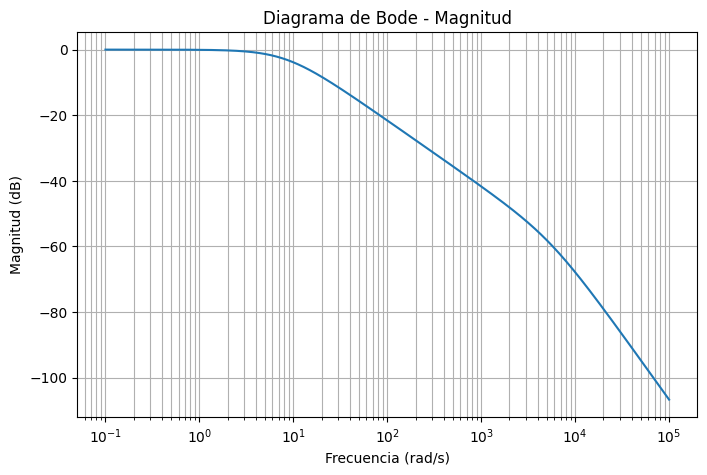

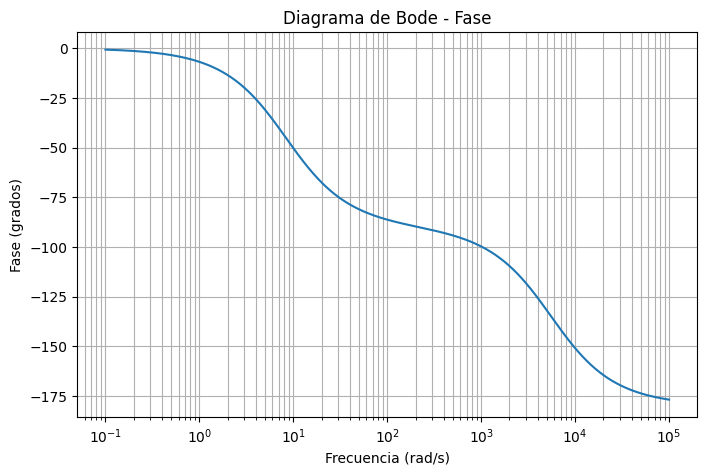


Ceros: []
Polos: [-5547.20968458    -8.34587097]


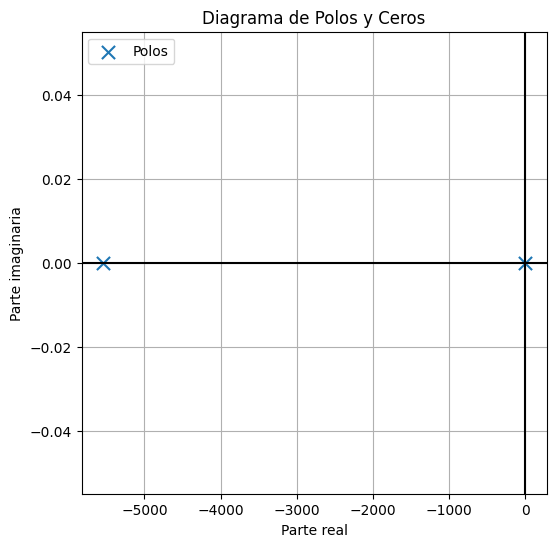

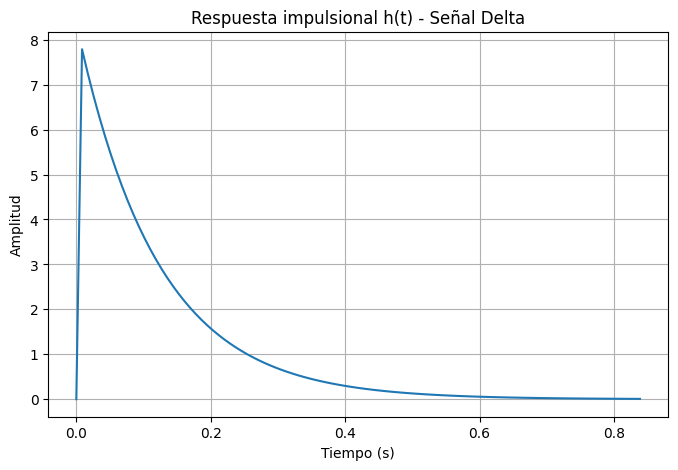

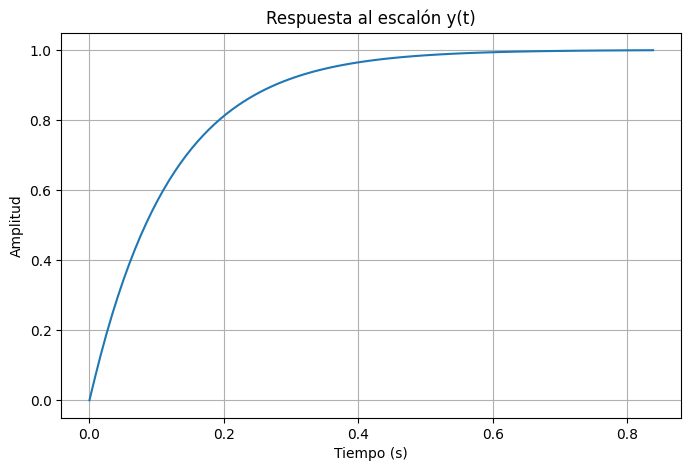

In [5]:
# ============================================
#   Análisis RLC por Transformada de Laplace
#   Bode – Polos y Ceros – Delta – Escalón
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sympy as sp

# -----------------------------
# 1. Parámetros del circuito
# -----------------------------
R = 1000
L = 0.18
C = 120e-6

# Variable simbólica de Laplace
s = sp.symbols('s')

# -----------------------------
# 2. Impedancias en dominio s
# -----------------------------
Z_L = s*L
Z_C = 1/(s*C)

# Función de transferencia desde Laplace:
H_s = Z_C / (R + Z_L + Z_C)
H_s = sp.simplify(H_s)

print("H(s) =", H_s)

# Coeficientes numéricos
num_sym, den_sym = sp.fraction(H_s)
num_poly = sp.Poly(num_sym, s)
den_poly = sp.Poly(den_sym, s)

num = [float(c) for c in num_poly.all_coeffs()]
den = [float(c) for c in den_poly.all_coeffs()]

print("\nNumerador =", num)
print("Denominador =", den)

# -----------------------------
# 3. Crear sistema continuo
# -----------------------------
sistema = signal.TransferFunction(num, den)

# -----------------------------
# 4. Bode
# -----------------------------
w = np.logspace(-1, 5, 2000)
w, mag, phase = signal.bode(sistema, w=w)

plt.figure(figsize=(8,5))
plt.semilogx(w, mag)
plt.title("Diagrama de Bode - Magnitud")
plt.xlabel("Frecuencia (rad/s)")
plt.ylabel("Magnitud (dB)")
plt.grid(True, which="both")
plt.show()

plt.figure(figsize=(8,5))
plt.semilogx(w, phase)
plt.title("Diagrama de Bode - Fase")
plt.xlabel("Frecuencia (rad/s)")
plt.ylabel("Fase (grados)")
plt.grid(True, which="both")
plt.show()

# -----------------------------
# 5. Polos y ceros
# -----------------------------
polos = np.roots(den)
ceros = np.roots(num)

print("\nCeros:", ceros)
print("Polos:", polos)

plt.figure(figsize=(6,6))
plt.axhline(0, color="black")
plt.axvline(0, color="black")

if len(ceros)>0:
    plt.scatter(ceros.real, ceros.imag, marker='o', s=70, label="Ceros")

plt.scatter(polos.real, polos.imag, marker='x', s=90, label="Polos")
plt.title("Diagrama de Polos y Ceros")
plt.xlabel("Parte real")
plt.ylabel("Parte imaginaria")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# 6. Respuesta impulsional (delta)
#   h(t) = L^{-1}{H(s)}
# -----------------------------
t, h = signal.impulse(sistema)

plt.figure(figsize=(8,5))
plt.plot(t, h)
plt.title("Respuesta impulsional h(t) - Señal Delta")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

# -----------------------------
# 7. Respuesta al escalón
#   y(t) = L^{-1}{ H(s)*(1/s) }
# -----------------------------
t2, y = signal.step(sistema)

plt.figure(figsize=(8,5))
plt.plot(t2, y)
plt.title("Respuesta al escalón y(t)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()